<a href="https://colab.research.google.com/github/Khushikumari24/AUS-Weather-Prediction/blob/main/YOLOv8_Real_Time_Object_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

install dependencies

In [1]:
# Install Ultralytics (YOLOv8's official open-source library)
!pip install ultralytics -q # The '!' runs a shell command inside Colab

# Install OpenCV for image/video manipulation
!pip install opencv-python-headless -q # 'headless' = no GUI window (needed in Colab)

# Optional: Roboflow for dataset APIs (free tier available)
!pip install roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 120.4 MB/s eta 0:00:00


Concept: Ultralytics is the company behind YOLOv8. The library is fully open-source (AGPL-3.0) and wraps everything — model loading, training, inference, export — in a clean Python API.


In [2]:
#Import Libraries

from ultralytics import YOLO    # Main class: load, train, predict, export
import cv2                       # OpenCV: read images, draw boxes, handle video
import numpy as np               # NumPy: array math (bounding box coords, masks)
from PIL import Image            # Pillow: open image files as PIL objects
import matplotlib.pyplot as plt  # Plot images inline in Colab
import torch                     # PyTorch: check if GPU is available

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
#verify GPU is active

# Check if CUDA (NVIDIA GPU) is detected by PyTorch
cuda_available = torch.cuda.is_available()
print(f"CUDA available: {cuda_available}") # True = T4 GPU ready

if cuda_available:
    print(f"GPU device name: {torch.cuda.get_device_name(0)}") # Prints "Tesla T4"
else:
    print("No CUDA-enabled GPU detected or PyTorch not compiled with CUDA.")

# Ultralytics auto-selects GPU if available — this just confirms it
device = 'cuda' if cuda_available else 'cpu'
print(f"Running on: {device}")

CUDA available: False
No CUDA-enabled GPU detected or PyTorch not compiled with CUDA.
Running on: cpu


In [4]:
#Cell 4 — Load a pretrained model

# Load YOLOv8 nano (smallest, fastest) pretrained on COCO dataset
model = YOLO('yolov8n.pt')
# 'yolov8n.pt' is auto-downloaded from Ultralytics CDN on first run (~6MB)

# Other options:
# YOLO('yolov8s.pt')  — small       (~22MB)
# YOLO('yolov8m.pt')  — medium      (~52MB)
# YOLO('yolov8l.pt')  — large       (~87MB)
# YOLO('yolov8x.pt')  — extra-large (~136MB)

Concept — COCO pretraining: The model was trained on the COCO dataset (330K images, 80 object classes including person, car, dog, chair, etc.). You're loading weights that already encode millions of learned visual features — no training needed for general detection.
Concept — .pt file: A PyTorch checkpoint containing the model architecture + learned weights. The YOLO class reads this and reconstructs the neural network in memory.

In [5]:
#Cell 5 — Run inference on an image

# Download a sample image
!wget https://ultralytics.com/images/bus.jpg -O test.jpg

# Run inference — this is all you need for detection
results = model.predict(
    source='test.jpg',    # Can be: file path, URL, numpy array, PIL image, webcam id
    conf=0.25,            # Confidence threshold: only show detections ≥ 25% confidence
    iou=0.45,             # IoU threshold for NMS (Non-Maximum Suppression)
    device=device,        # Use GPU if available
    save=True,            # Save annotated image to runs/detect/predict/
    verbose=True          # Print per-image detection summary
)

--2026-05-27 10:34:51--  https://ultralytics.com/images/bus.jpg
Resolving ultralytics.com (ultralytics.com)... 216.150.1.1
Connecting to ultralytics.com (ultralytics.com)|216.150.1.1|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: https://www.ultralytics.com/images/bus.jpg [following]
--2026-05-27 10:34:51--  https://www.ultralytics.com/images/bus.jpg
Resolving www.ultralytics.com (www.ultralytics.com)... 216.150.1.193, 216.150.16.193
Connecting to www.ultralytics.com (www.ultralytics.com)|216.150.1.193|:443... connected.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg [following]
--2026-05-27 10:34:51--  https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Lo

Concept — Confidence threshold (conf): Each detection has a probability score (0–1). Setting conf=0.25 means "only keep detections where the model is ≥25% sure an object exists." Higher = fewer but more reliable boxes.
Concept — IoU (Intersection over Union): Measures how much two bounding boxes overlap. IoU = area_of_overlap / area_of_union. Used in NMS to remove duplicate boxes for the same object.

Concept — NMS (Non-Maximum Suppression): YOLOv8 generates hundreds of candidate boxes. NMS keeps only the best box per object by: (1) sorting by confidence, (2) removing boxes that overlap the best box by more than the iou threshold. Without NMS you'd get 20 overlapping boxes around one car.

In [6]:
#Cell 6 — Explore results programmatically

for result in results:                    # Loop over each image's results
    boxes = result.boxes                  # Bounding box tensor object

    # Extract numpy arrays for each property
    xyxy = boxes.xyxy.cpu().numpy()       # Box coords: [x1, y1, x2, y2] in pixels
    conf = boxes.conf.cpu().numpy()       # Confidence scores per box: [0.87, 0.73, ...]
    cls  = boxes.cls.cpu().numpy()        # Class indices: [0, 2, 5, ...] → person, car, bus

    # Human-readable class names
    names = result.names                  # Dict: {0: 'person', 1: 'bicycle', 2: 'car', ...}

    for i in range(len(xyxy)):
        x1, y1, x2, y2 = xyxy[i].astype(int)   # Pixel coordinates
        label = names[int(cls[i])]               # 'person', 'car', etc.
        score = conf[i]                          # e.g. 0.873

        print(f"{label}: {score:.2f} | box: [{x1},{y1},{x2},{y2}]")

bus: 0.87 | box: [22,231,805,756]
person: 0.87 | box: [48,398,245,902]
person: 0.85 | box: [669,392,809,877]
person: 0.83 | box: [221,405,344,857]
person: 0.26 | box: [0,550,63,873]
stop sign: 0.26 | box: [0,254,32,324]


Concept — .cpu().numpy(): Results live on GPU memory by default. .cpu() moves tensors to RAM, .numpy() converts PyTorch tensors to NumPy arrays you can work with normally.

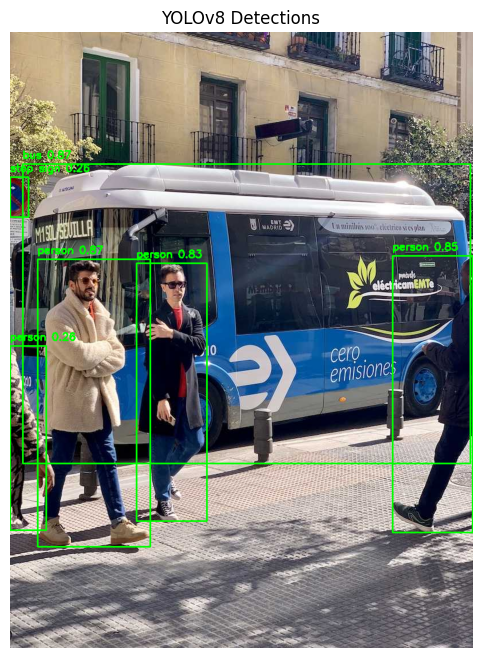

In [7]:
#Cell 7 — Custom visualisation with OpenCV

img = cv2.imread('test.jpg')               # Load image as (H, W, 3) BGR NumPy array
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR→RGB (OpenCV uses BGR!)

for result in results:
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())  # Unpack 4 coords
        label = result.names[int(box.cls[0])]                  # Class name string
        confidence = float(box.conf[0])                        # Float 0.0–1.0

        # Draw filled rectangle for the box
        cv2.rectangle(img_rgb,
                      (x1, y1), (x2, y2),  # Top-left and bottom-right corners
                      (0, 255, 0),          # Color: green in RGB
                      2)                    # Line thickness in pixels

        # Draw label text above the box
        label_text = f"{label} {confidence:.2f}"
        cv2.putText(img_rgb,
                    label_text,
                    (x1, y1 - 10),          # Position: 10px above the box top
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,                    # Font scale (relative size)
                    (0, 255, 0),            # Text color: green
                    2)                      # Thickness

# Display inline in Colab
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis('off')                            # Hide x/y axes — not useful here
plt.title('YOLOv8 Detections')
plt.show()

In [8]:
#Cell 8 — Inference on a video file

# Download sample video
!wget https://ultralytics.com/assets/decelera_landscape_min.mov -O test.mp4

results = model.predict(
    source='test.mp4',    # Path to video file
    conf=0.4,
    save=True,            # Saves annotated video to runs/detect/predict2/
    stream=True,          # Yields results frame-by-frame (memory efficient!)
)

# Stream processes each frame lazily — no loading entire video into RAM
for frame_result in results:
    # frame_result.boxes contains detections for THIS frame
    pass   # Replace with your per-frame logic

--2026-05-27 11:13:37--  https://ultralytics.com/assets/decelera_landscape_min.mov
Resolving ultralytics.com (ultralytics.com)... 216.150.1.1
Connecting to ultralytics.com (ultralytics.com)|216.150.1.1|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: https://www.ultralytics.com/assets/decelera_landscape_min.mov [following]
--2026-05-27 11:13:37--  https://www.ultralytics.com/assets/decelera_landscape_min.mov
Resolving www.ultralytics.com (www.ultralytics.com)... 216.150.1.65, 216.150.16.65
Connecting to www.ultralytics.com (www.ultralytics.com)|216.150.1.65|:443... connected.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://github.com/ultralytics/assets/releases/download/v0.0.0/decelera_landscape_min.mov [following]
--2026-05-27 11:13:37--  https://github.com/ultralytics/assets/releases/download/v0.0.0/decelera_landscape_min.mov
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github

Concept — stream=True: Instead of loading the whole video and returning a list of all results, streaming is a Python generator that yields one frame at a time. Essential for long videos to avoid OOM (out of memory) errors.

<IPython.core.display.Javascript object>


image 1/1 /content/webcam.jpg: 480x640 1 person, 1 chair, 191.5ms
Speed: 2.7ms preprocess, 191.5ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


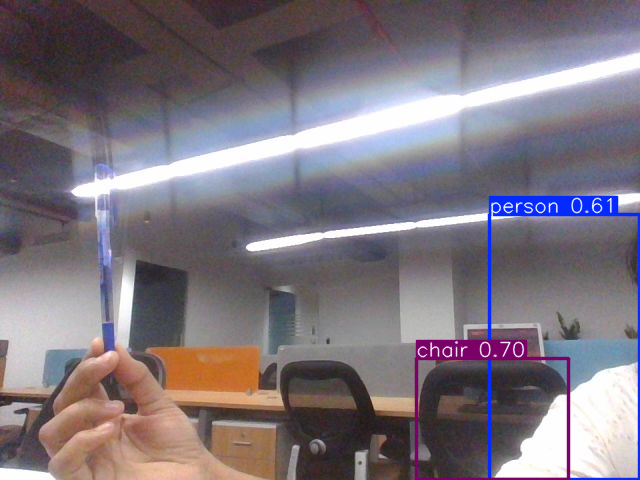

In [13]:
#Cell 9 — Real-time with webcam (Colab trick)

# Colab has no direct webcam access — use JavaScript to capture a frame
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import PIL

def capture_photo():
    js = Javascript('''
        async function takePhoto() {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = 'Capture';
          div.appendChild(capture);
          document.body.appendChild(div);

          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          const video = document.createElement('video');
          video.srcObject = stream;
          await video.play();
          div.appendChild(video);

          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getTracks().forEach(track => track.stop());
          div.remove();
          return canvas.toDataURL('image/jpeg', 0.8);  // Base64 JPEG
        }
        takePhoto()
    ''')
    display(js)
    data = eval_js('takePhoto()')          # Wait for JS promise to resolve
    binary = b64decode(data.split(',')[1]) # Decode base64 to bytes
    with open('webcam.jpg', 'wb') as f:
        f.write(binary)                    # Save to disk

capture_photo()

# Now detect on the captured frame
results = model.predict('webcam.jpg', conf=0.4)
results[0].show()   # Display inline with built-in annotated plot